In [7]:
 # Sales Prediction using Python 
import pandas as pd
df = pd.read_csv("Advertising.csv")
print(df.head())
print(df.info())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [13]:
# Identifying duplicate records
print("Duplicate Rows: ", df.duplicated())

# Removing the unnecessary column
df = df.drop('Unnamed: 0', axis=1)

Duplicate Rows:  0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool


In [14]:
# Identifying column dtypes
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("Categorical Column", cat_col)
print("Numerical Column", num_col)

Categorical Column []
Numerical Column ['TV', 'Radio', 'Newspaper', 'Sales']


In [15]:
# Calculating Missing values
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [16]:
# Exploratory Data Analysis (EDA)
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


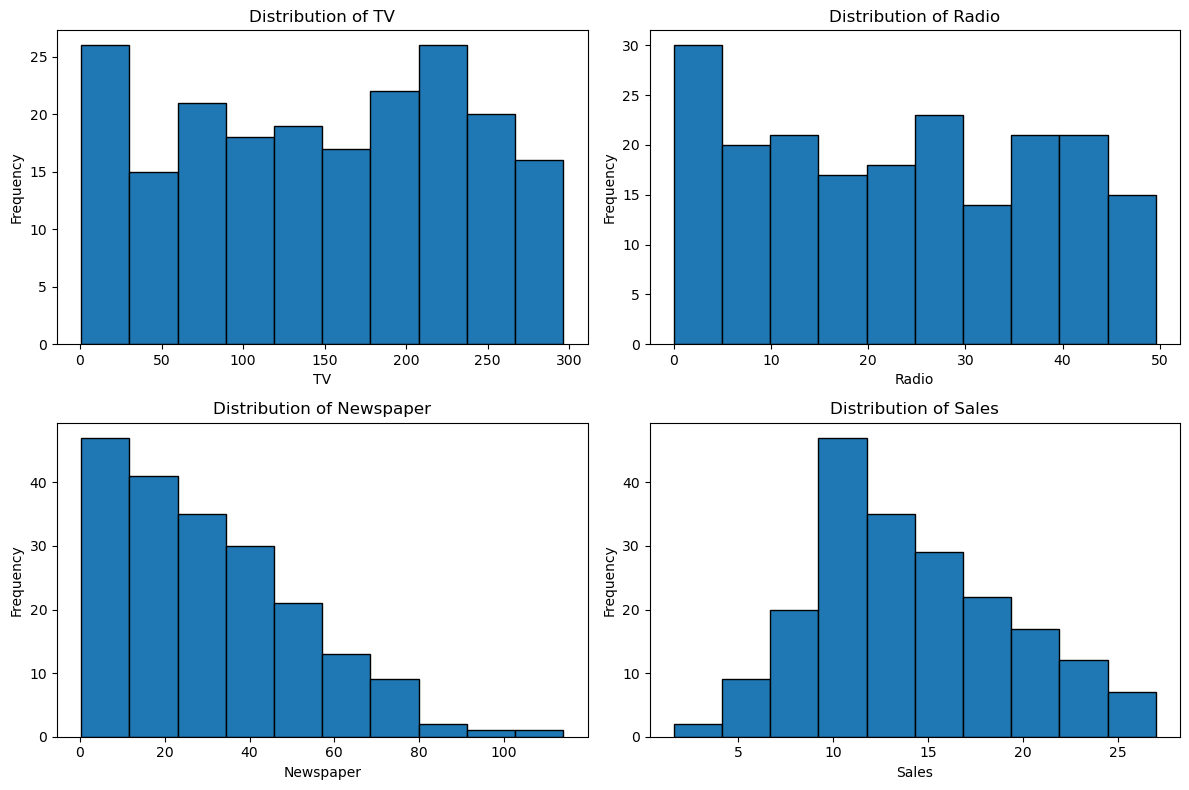

In [26]:
import matplotlib.pyplot as plt

columns = ['TV', 'Radio', 'Newspaper', 'Sales']

plt.figure(figsize=(12, 8))

for i, column in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[column], bins=10, edgecolor='black')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

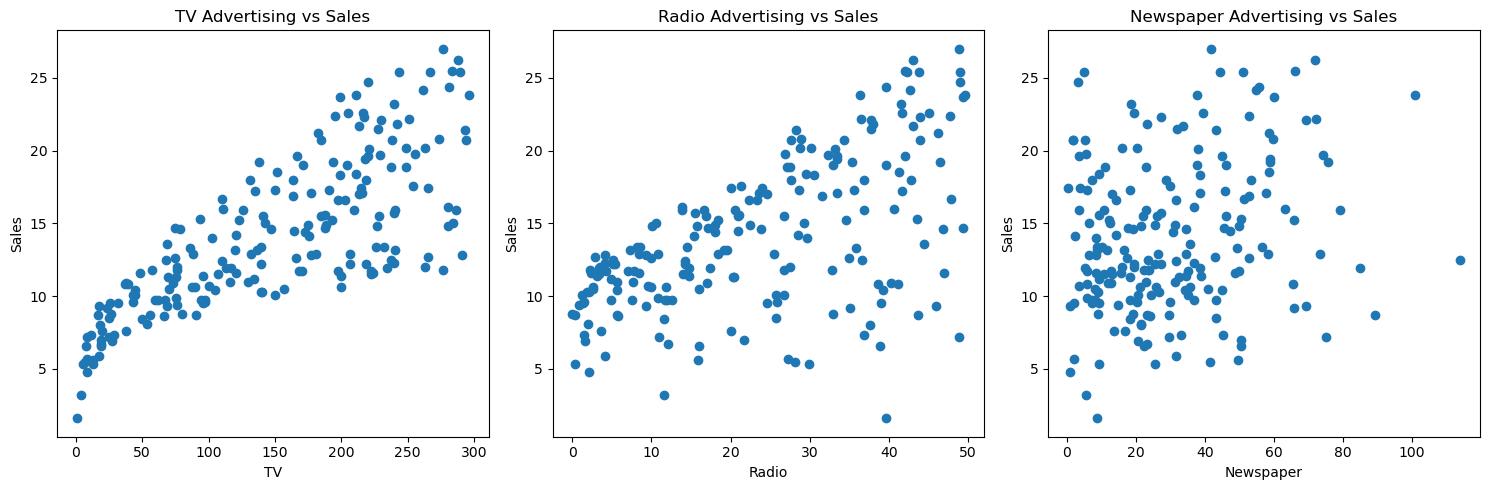

In [27]:
# Relationship between Advertising and Sales
# Advertising vs Sales 

import matplotlib.pyplot as plt

advertising_columns = ['TV', 'Radio', 'Newspaper']

plt.figure(figsize=(15, 5))

for i, column in enumerate(advertising_columns, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df[column], df['Sales'])
    plt.xlabel(column)
    plt.ylabel('Sales')
    plt.title(f'{column} Advertising vs Sales')

plt.tight_layout()
plt.show()

In [25]:
# Correlation
df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


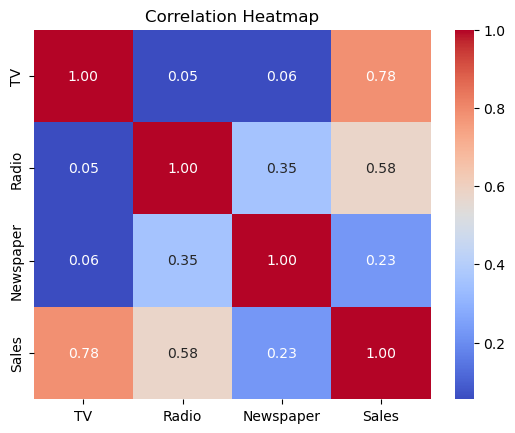

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [29]:
# Feature Engineering

df['Total_Advertising'] = (
    df['TV'] +
    df['Radio'] +
    df['Newspaper']
)
df[['TV', 'Radio', 'Newspaper', 'Total_Advertising', 'Sales']].corr()

,TV,Radio,Newspaper,Total_Advertising,Sales
TV,1.000000,0.054809,0.056648,0.945330,0.782224
Radio,0.054809,1.000000,0.354104,0.293211,0.576223
Newspaper,0.056648,0.354104,1.000000,0.343059,0.228299
Total_Advertising,0.945330,0.293211,0.343059,1.000000,0.867712
Sales,0.782224,0.576223,0.228299,0.867712,1.000000


In [44]:
# Feature Selection

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(X.head())
print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [45]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Verify the split

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


In [46]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [47]:
# Building the model Linear Regression

from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display the learned parameters
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

# Make predictions
y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])

Intercept: 2.9790673381226274
TV : 0.044729517468716326
Radio : 0.1891950542343766
Newspaper : 0.0027611143413671874

First 10 predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [36]:
# Calculate the metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.4607567168117606
MSE: 3.1740973539761055
RMSE: 1.7815996615334506
R²: 0.899438024100912


In [38]:
# Let's  compare actual vs predicted

# Flatten the arrays to 1D using .flatten() or .ravel()
comparison = pd.DataFrame({
    'Actual Sales': y_test.values.ravel(),
    'Predicted Sales': y_pred.ravel()
})

print(comparison.head(10))


   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373
5          12.6        13.105592
6          22.3        21.057192
7           8.4         7.461010
8          11.5        13.606346
9          14.9        15.155070


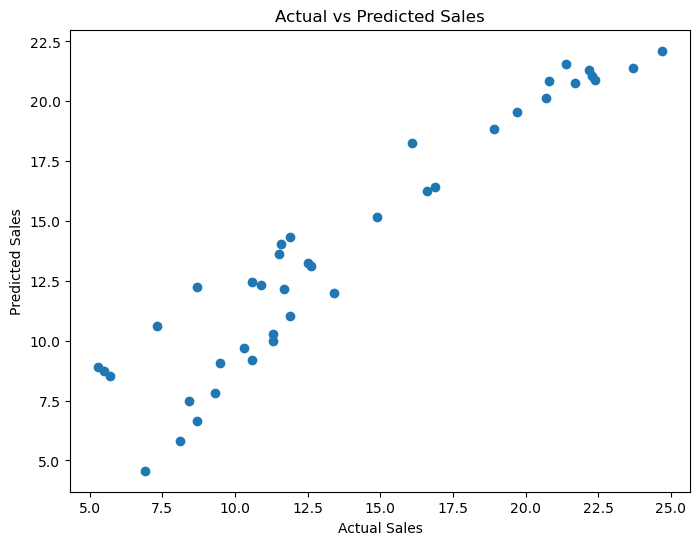

In [48]:
# visualize Actual vs Predicted Sales.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

In [49]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient}")

Intercept: 2.9790673381226274
TV: 0.044729517468716326
Radio: 0.1891950542343766
Newspaper: 0.0027611143413671874


In [50]:
# Calculating residuals

residuals = y_test - y_pred

print(residuals.head(10))
print("Mean Residual:", residuals.mean())

95     0.491976
15     1.510118
30    -0.153843
158   -3.308503
128    2.587627
115   -0.505592
69     1.242808
170    0.938990
174   -2.106346
45    -0.255070
Name: Sales, dtype: float64
Mean Residual: -0.09752119905509951


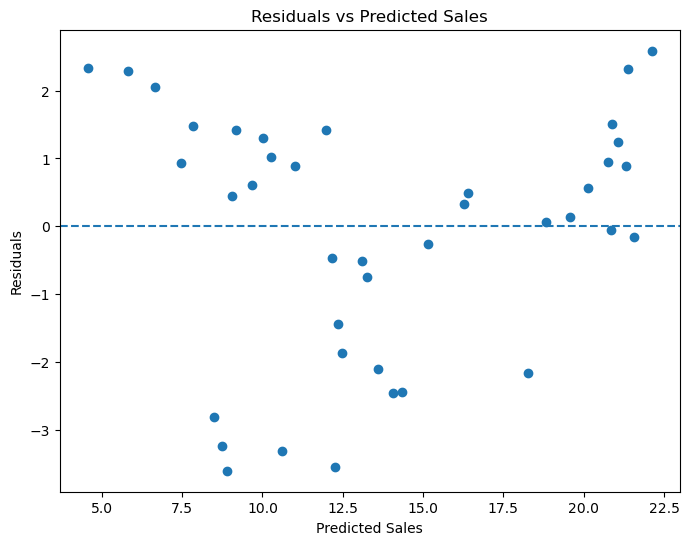

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Sales')

plt.show()

In [52]:
# Predict Sales for a New Advertising Campaign
new_campaign = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [30]
})

print(new_campaign)

    TV  Radio  Newspaper
0  200     40         30


In [54]:
# Making prediction
predicted_sales = model.predict(new_campaign)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 19.575606431481972


In [55]:
campaigns = pd.DataFrame({
    'TV': [200, 250, 200, 200],
    'Radio': [40, 40, 60, 40],
    'Newspaper': [30, 30, 30, 50]
})

campaigns['Predicted_Sales'] = model.predict(
    campaigns[['TV', 'Radio', 'Newspaper']]
)

print(campaigns)

    TV  Radio  Newspaper  Predicted_Sales
0  200     40         30        19.575606
1  250     40         30        21.812082
2  200     60         30        23.359508
3  200     40         50        19.630829
